# Diabetes Prediction | Single LGBM
### Single Model
#### Sudmission
# Score: NA


In [1]:
!pip install session-info

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 2.1 MB/s eta 0:00:00


In [2]:
import logging
import math
import os
import time
import warnings
import session_info

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from optuna.samplers import TPESampler
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import KFold,  train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

rand_seed = 7

In [3]:
train_df = pd.read_csv("/kaggle/input/playground-series-s5e12/train.csv")
train_df = train_df.drop("id", axis=1)
test_df = pd.read_csv("/kaggle/input/playground-series-s5e12/test.csv")
test_df = test_df.drop("id", axis=1)

submission = pd.read_csv("/kaggle/input/playground-series-s5e12/sample_submission.csv")

In [4]:
train_df.shape

(700000, 25)

In [5]:
orig_df = pd.read_csv("/kaggle/input/diabetes-health-indicators-dataset/diabetes_dataset.csv")

orig_df.shape

(100000, 31)

In [6]:
diff_cols = orig_df.columns.difference(train_df.columns).to_list()
orig_df = orig_df.drop(['diabetes_risk_score',
 'diabetes_stage',
 'glucose_fasting',
 'glucose_postprandial',
 'hba1c',
 'insulin_level'], axis = 1)

train_df = pd.concat([train_df, orig_df])
print(orig_df.columns.difference(train_df.columns).to_list())

print(train_df.shape)

[]
(800000, 25)


In [7]:
test_df.head()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history
0,45,4,100,4.3,6.8,6.2,25.5,0.84,123,70,...,111,Female,White,Highschool,Middle,Former,Employed,0,0,0
1,35,1,87,3.5,4.6,9.0,28.6,0.88,120,74,...,145,Female,White,Highschool,Middle,Never,Unemployed,0,0,0
2,45,1,61,7.6,6.8,7.0,28.5,0.94,112,71,...,184,Male,White,Highschool,Low,Never,Employed,0,0,0
3,55,2,81,7.3,7.3,5.0,26.9,0.91,114,81,...,128,Male,White,Graduate,Middle,Former,Employed,0,0,0
4,77,2,29,7.3,7.6,8.5,22.0,0.83,131,78,...,133,Male,White,Graduate,Low,Current,Unemployed,0,0,0


## EDA

In [8]:
print(train_df.info())
print("i" * 100)
print(test_df.info())
print("i" * 100)

<class 'pandas.core.frame.DataFrame'>
Index: 800000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 800000 non-null  int64  
 1   alcohol_consumption_per_week        800000 non-null  int64  
 2   physical_activity_minutes_per_week  800000 non-null  int64  
 3   diet_score                          800000 non-null  float64
 4   sleep_hours_per_day                 800000 non-null  float64
 5   screen_time_hours_per_day           800000 non-null  float64
 6   bmi                                 800000 non-null  float64
 7   waist_to_hip_ratio                  800000 non-null  float64
 8   systolic_bp                         800000 non-null  int64  
 9   diastolic_bp                        800000 non-null  int64  
 10  heart_rate                          800000 non-null  int64  
 11  cholesterol_total               

In [9]:
train_df.describe().style.background_gradient(cmap='Greens')

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000
mean,50.329819,2.063819,85.065907,5.967581,7.001652,6.010700,25.841930,0.858430,116.232370,75.414870,70.100889,186.713715,53.850661,102.917676,122.879450,0.158153,0.190591,0.036434,0.620381
std,12.219398,1.101426,57.858291,1.506739,0.928187,2.083645,2.962470,0.039207,11.471964,7.013251,7.135828,19.316077,8.542618,21.353785,27.766268,0.364884,0.392768,0.187367,0.485292
min,18.000000,0.000000,0.000000,0.000000,3.000000,0.500000,15.000000,0.670000,90.000000,50.000000,40.000000,100.000000,20.000000,50.000000,30.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.800000,0.830000,108.000000,71.000000,65.000000,174.000000,48.000000,88.000000,105.000000,0.000000,0.000000,0.000000,0.000000
50%,50.000000,2.000000,73.000000,6.000000,7.000000,6.000000,25.800000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,59.000000,3.000000,101.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,200.000000,60.000000,117.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,90.000000,10.000000,833.000000,10.000000,10.000000,16.800000,39.200000,1.060000,179.000000,110.000000,105.000000,318.000000,98.000000,263.000000,344.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
test_df.describe().style.background_gradient(cmap='Blues')

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,50.432397,2.089693,92.349087,5.945838,6.997795,6.011278,25.881906,0.859007,116.374117,75.396013,70.048350,187.308620,53.813557,103.416083,123.538480,0.152920,0.184410,0.033110
std,11.938741,1.066214,62.187399,1.481068,0.914693,2.060472,2.894289,0.038523,11.252146,6.950340,7.090543,18.413053,8.398126,20.571855,28.965441,0.359911,0.387819,0.178924
min,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.690000,91.000000,51.000000,42.000000,107.000000,22.000000,51.000000,31.000000,0.000000,0.000000,0.000000
25%,42.000000,1.000000,51.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,174.000000,48.000000,89.000000,104.000000,0.000000,0.000000,0.000000
50%,50.000000,2.000000,77.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000
75%,59.000000,3.000000,115.000000,7.000000,7.600000,7.400000,27.800000,0.890000,124.000000,80.000000,75.000000,200.000000,60.000000,117.000000,142.000000,0.000000,0.000000,0.000000
max,89.000000,9.000000,748.000000,9.900000,9.900000,15.900000,38.300000,1.050000,170.000000,104.000000,101.000000,285.000000,91.000000,226.000000,290.000000,1.000000,1.000000,1.000000


### Null Values

In [11]:
print(" ")
print(" Train Data")
print(" ")
print(train_df.isnull().sum())
print(" ")
print(" Test Data")
print(" ")
print(test_df.isnull().sum())
print(" ")

 
 Train Data
 
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
diagnosed_diabetes      

### Categorical Data Type!

In [12]:
cat_cols = train_df.select_dtypes(include="object").columns.to_list()
num_cols = train_df.select_dtypes(include="number").columns.to_list()
num_cols_no_tar = num_cols[0:5]

for col_name in cat_cols:
    print(
        f"{col_name} \n ***Train_df***-> {train_df[col_name].value_counts()} \n\n ***Test_df*** -> {test_df[col_name].value_counts()} \n\n"
    )

gender 
 ***Train_df***-> gender
Female    413453
Male      380856
Other       5691
Name: count, dtype: int64 

 ***Test_df*** -> gender
Female    154098
Male      144102
Other       1800
Name: count, dtype: int64 


ethnicity 
 ***Train_df***-> ethnicity
White       431150
Hispanic    150087
Black       124287
Asian        71985
Other        22491
Name: count, dtype: int64 

 ***Test_df*** -> ethnicity
White       168375
Hispanic     53534
Black        45203
Asian        25077
Other         7811
Name: count, dtype: int64 


education_level 
 ***Train_df***-> education_level
Highschool      389036
Graduate        296305
Postgraduate     94614
No formal        20045
Name: count, dtype: int64 

 ***Test_df*** -> education_level
Highschool      153355
Graduate        105440
Postgraduate     34118
No formal         7087
Name: count, dtype: int64 


income_level 
 ***Train_df***-> income_level
Middle          325709
Lower-Middle    203720
Upper-Middle    147702
Low             100633
High  

In [13]:
strata_sample = train_df.groupby('diagnosed_diabetes', sort = False).apply(
    lambda x: x.sample(frac=0.15)
).droplevel(0).sample(frac=1, random_state=rand_seed)
 
strata_sample

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
146500,44,1,38,6.3,8.1,3.7,23.0,0.87,123,79,...,Female,White,Postgraduate,Upper-Middle,Former,Employed,0,0,0,1.0
69196,32,3,59,5.1,7.0,5.0,24.9,0.84,102,71,...,Female,White,Graduate,Middle,Never,Retired,1,0,0,1.0
621411,60,3,192,7.0,6.2,5.7,22.1,0.79,123,77,...,Male,Hispanic,Highschool,Middle,Former,Employed,1,0,0,1.0
311339,59,1,67,9.1,8.2,5.9,25.1,0.85,123,69,...,Male,White,Graduate,Upper-Middle,Never,Employed,0,0,0,0.0
244518,68,2,36,4.1,7.6,10.0,28.9,0.87,139,78,...,Male,Black,Graduate,Middle,Former,Employed,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,42,1,412,8.3,6.1,6.5,28.8,0.91,125,64,...,Male,White,Highschool,Lower-Middle,Former,Unemployed,0,0,1,0.0
617707,43,1,92,5.0,9.1,7.3,24.5,0.84,110,81,...,Female,Black,Graduate,Low,Current,Employed,0,0,0,1.0
425895,69,1,93,6.0,7.6,4.8,26.3,0.87,130,73,...,Male,White,Highschool,Lower-Middle,Never,Employed,0,0,0,1.0
336431,68,1,71,5.3,5.8,4.8,24.7,0.84,116,90,...,Female,Hispanic,Highschool,Middle,Never,Retired,1,1,0,1.0


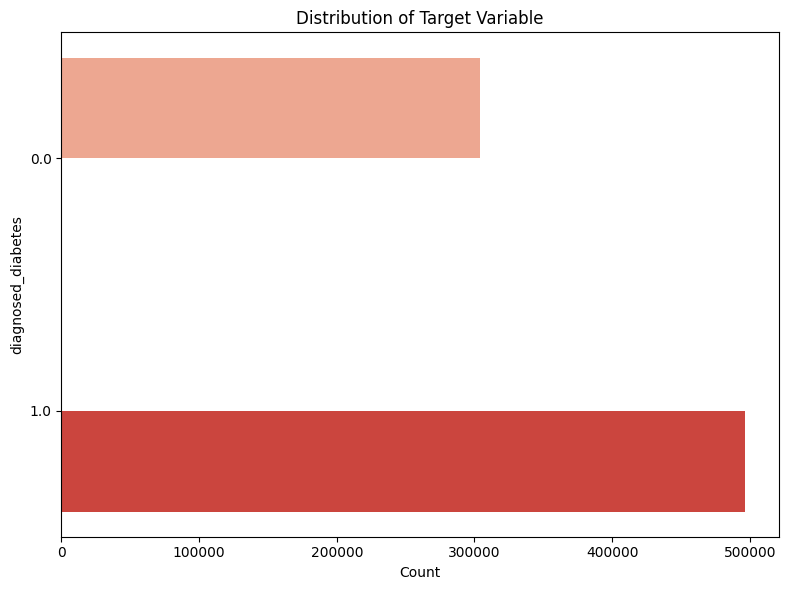

In [14]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    y="diagnosed_diabetes", data=train_df, hue="diagnosed_diabetes", palette="Reds"
)
plt.title("Distribution of Target Variable")
plt.ylabel("diagnosed_diabetes")
plt.xlabel("Count")
plt.legend().remove()
plt.tight_layout()
plt.show()

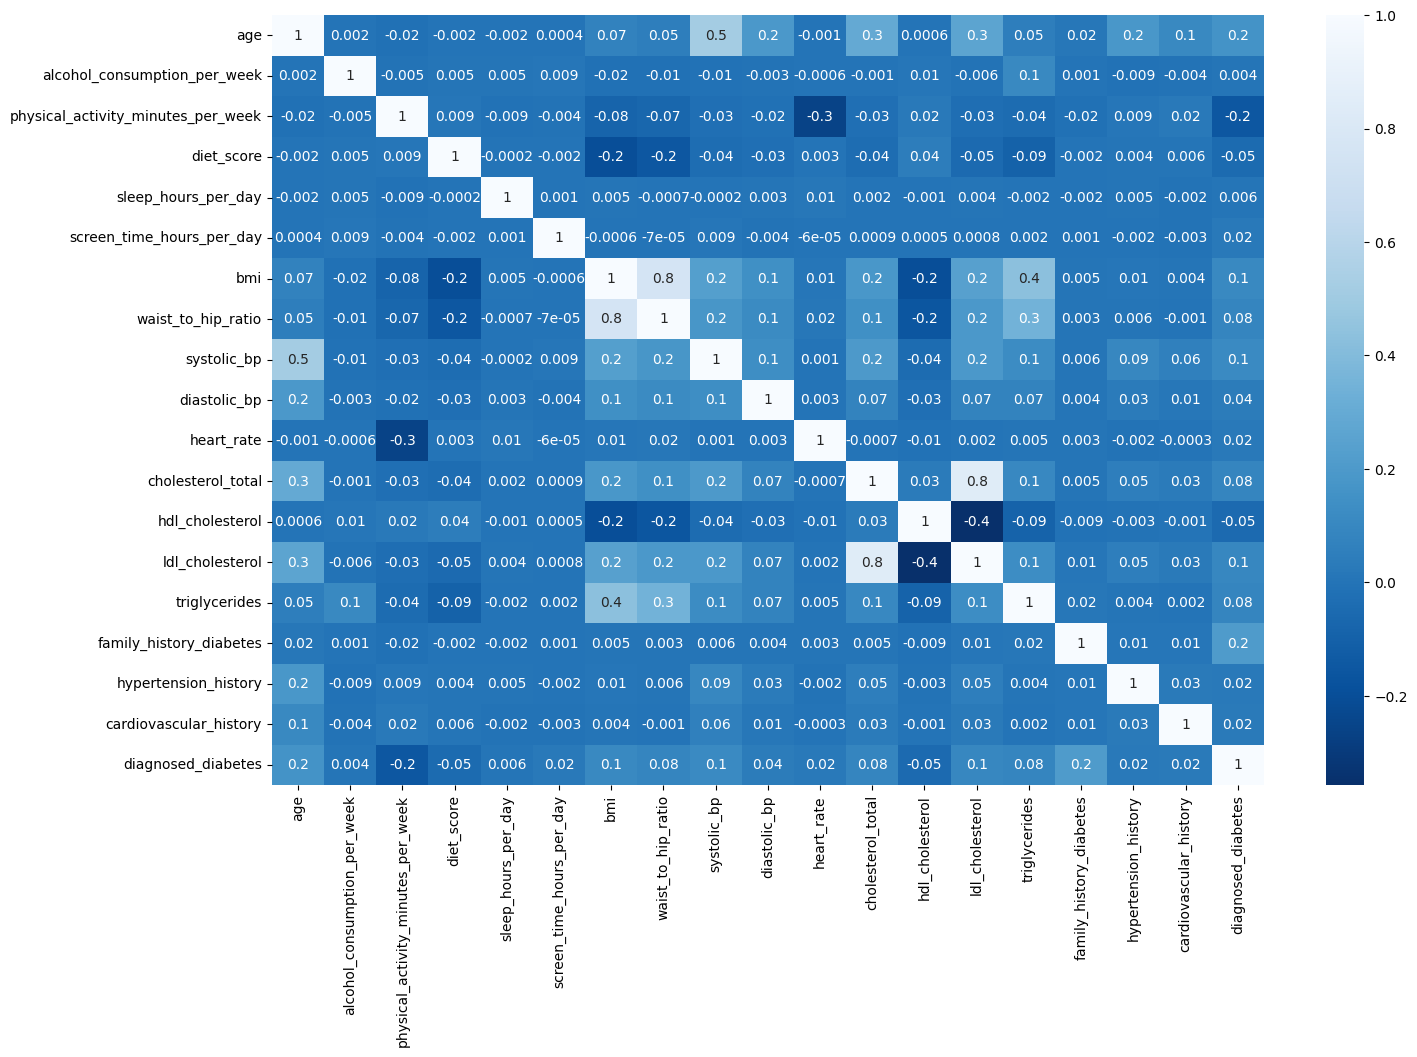

In [15]:
plt.figure(figsize = (16, 10))
sns.heatmap(data=strata_sample[num_cols].corr(), annot = True, fmt='.1g', cmap = "Blues_r" )
plt.show()

In [16]:
palette_sex={"Female" : "#c90076", "Male": "#2986CC", "Other":"#cccccc"}

palette_01={1: "#d9534f", 0: "#5cb85c"}

pal_ethnicity= {"White": "#ece0d1", "Hispanic": "#fc913a", "Black": "#36454f", "Asian": "#009688", "Other":"#989898"}


def plotlm(x_var, y_var, row_var, pal = None):
    sns.lmplot(
        data=strata_sample,
        x=x_var,
        y=y_var,
        row=row_var,
        hue = row_var,
        lowess=True,
        height=2,
        aspect=4,
        palette= pal,
        col="diagnosed_diabetes",
        line_kws={"color": "#23272a"},
        scatter_kws={"alpha": 0.3},
    )
    plt.suptitle(
         f"{x_var.replace('_', ' ').title()} VS {y_var.replace('_', ' ').title()} And {row_var.replace('_', ' ').title()} by Target Variable",
        y=1.02,
        fontsize=16,
    )
    plt.show()

# Gender

In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 800000 non-null  int64  
 1   alcohol_consumption_per_week        800000 non-null  int64  
 2   physical_activity_minutes_per_week  800000 non-null  int64  
 3   diet_score                          800000 non-null  float64
 4   sleep_hours_per_day                 800000 non-null  float64
 5   screen_time_hours_per_day           800000 non-null  float64
 6   bmi                                 800000 non-null  float64
 7   waist_to_hip_ratio                  800000 non-null  float64
 8   systolic_bp                         800000 non-null  int64  
 9   diastolic_bp                        800000 non-null  int64  
 10  heart_rate                          800000 non-null  int64  
 11  cholesterol_total               

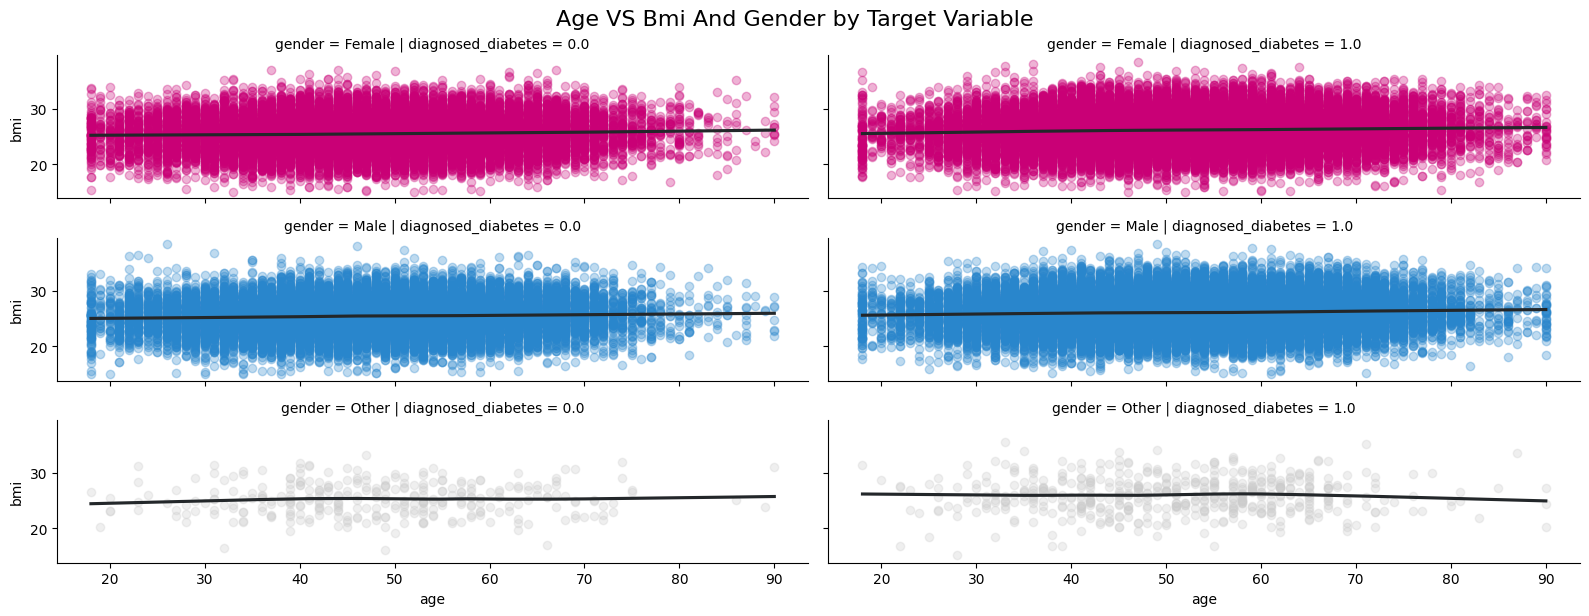

In [18]:
plotlm(x_var = "age" , y_var = "bmi", row_var = "gender", pal = palette_sex )

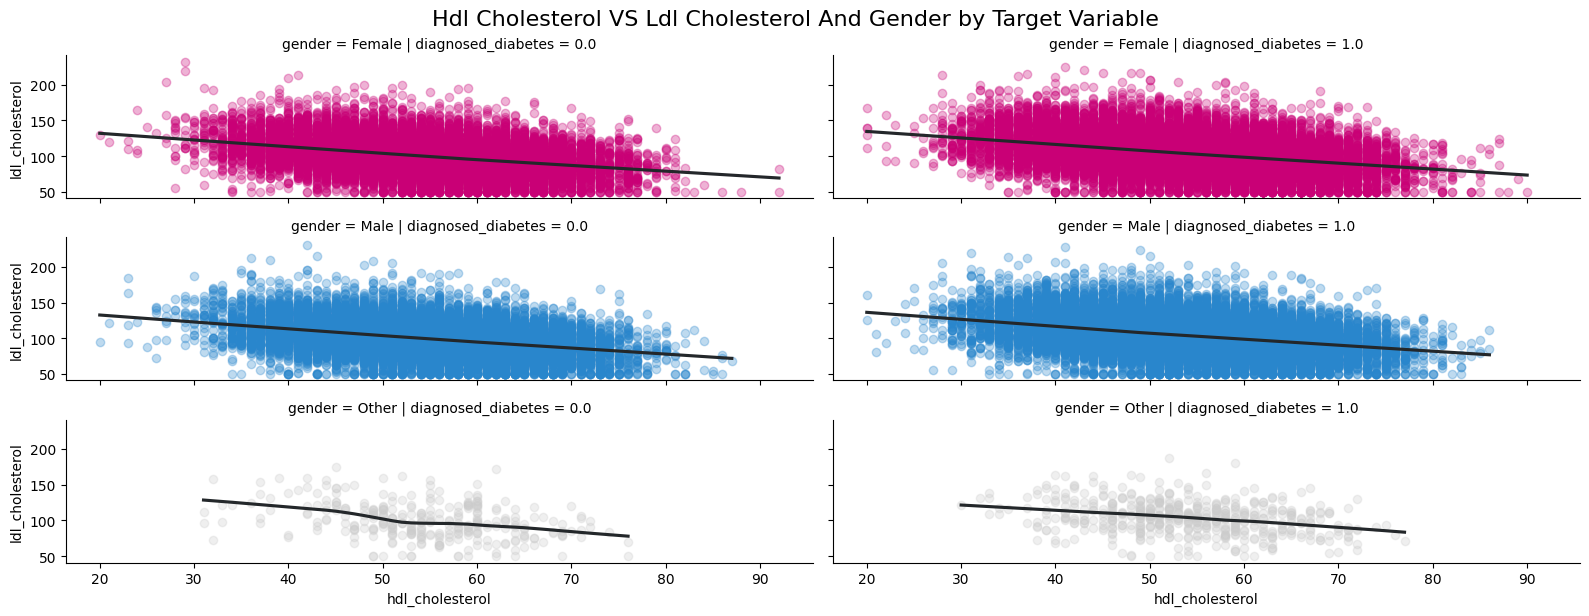

In [19]:
plotlm(x_var = "hdl_cholesterol" , y_var = "ldl_cholesterol", row_var = "gender", pal = palette_sex)

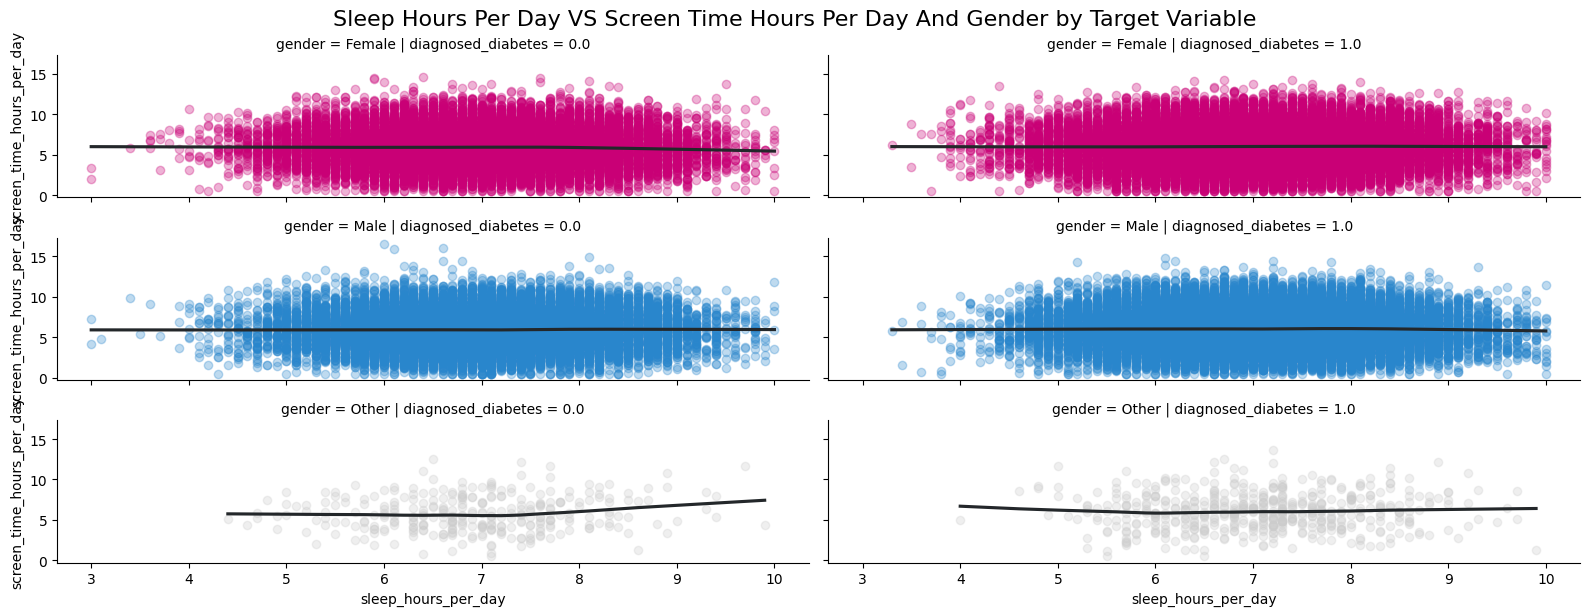

In [20]:
plotlm(x_var = "sleep_hours_per_day" , y_var = "screen_time_hours_per_day", row_var = "gender" , pal = palette_sex)

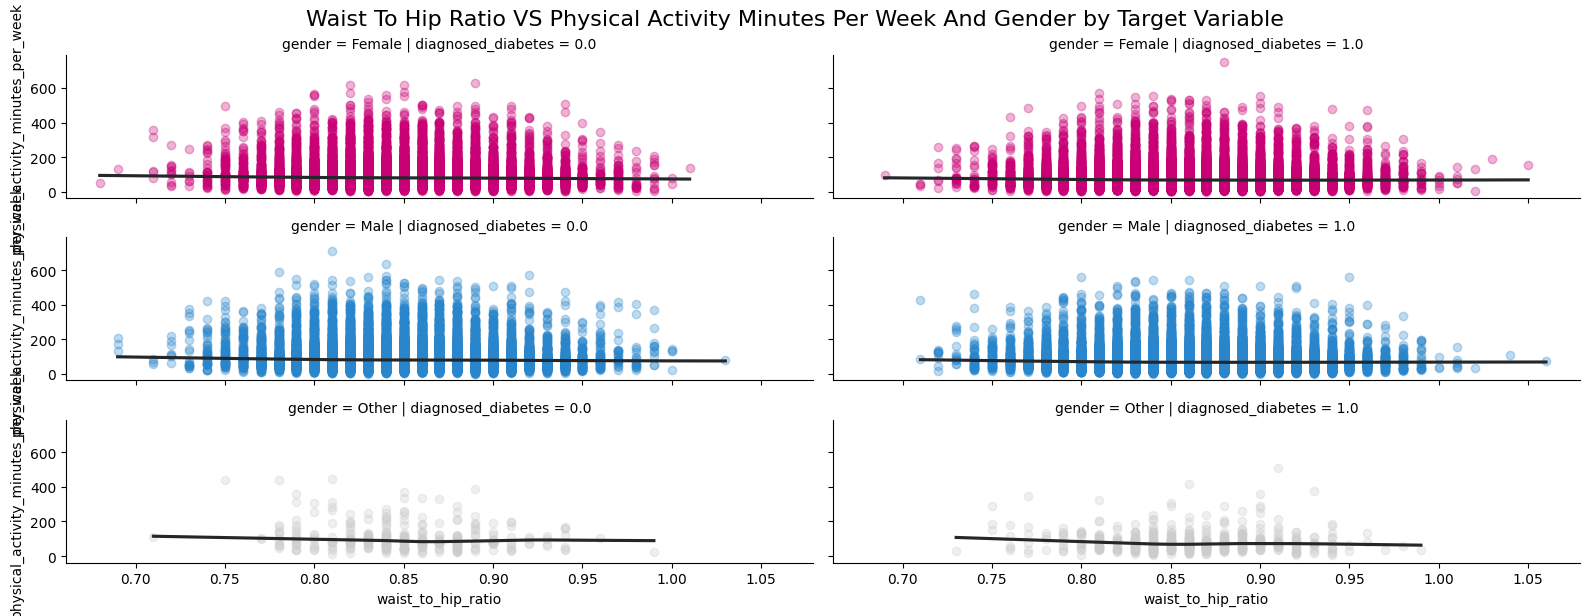

In [21]:
plotlm(x_var = "waist_to_hip_ratio" , y_var = "physical_activity_minutes_per_week", row_var = "gender", pal = palette_sex)

# Family history diabetes

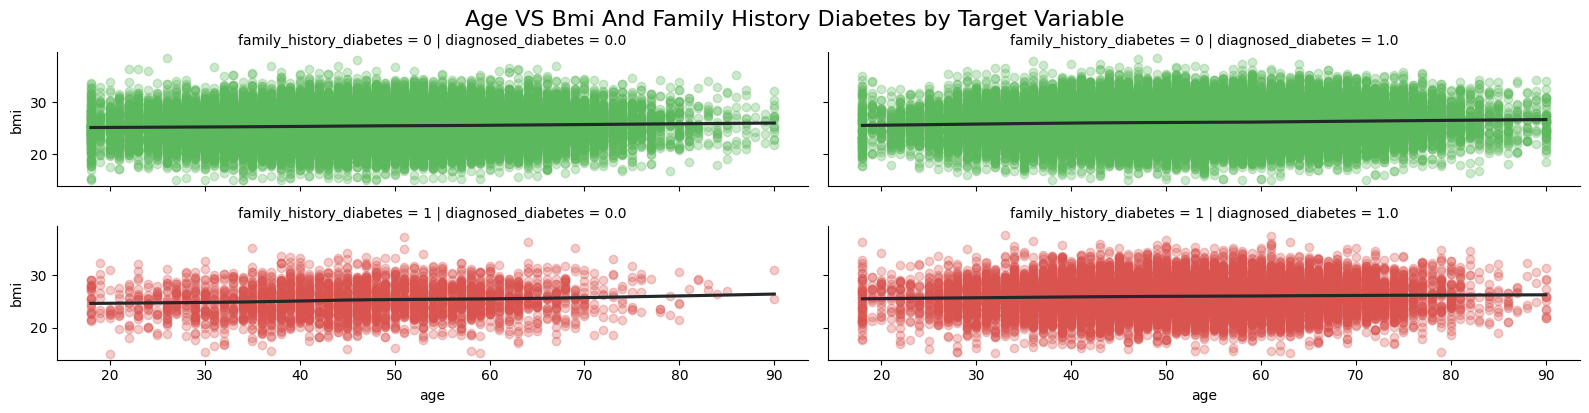

In [22]:
plotlm(x_var = "age" , y_var = "bmi",  row_var = "family_history_diabetes", pal = palette_01)

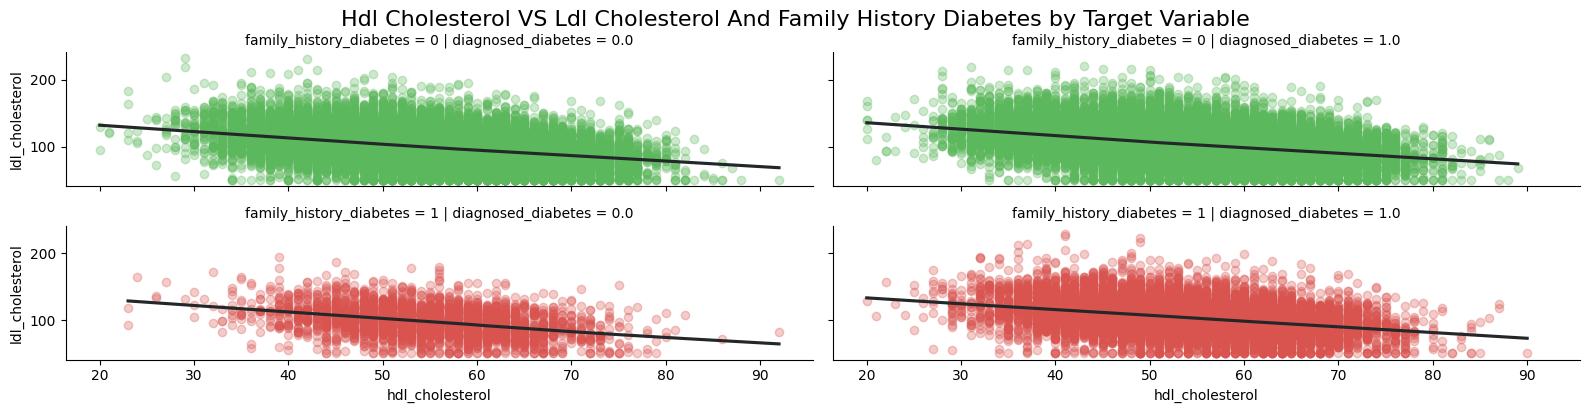

In [23]:
plotlm(x_var = "hdl_cholesterol" , y_var = "ldl_cholesterol", row_var = "family_history_diabetes", pal = palette_01)

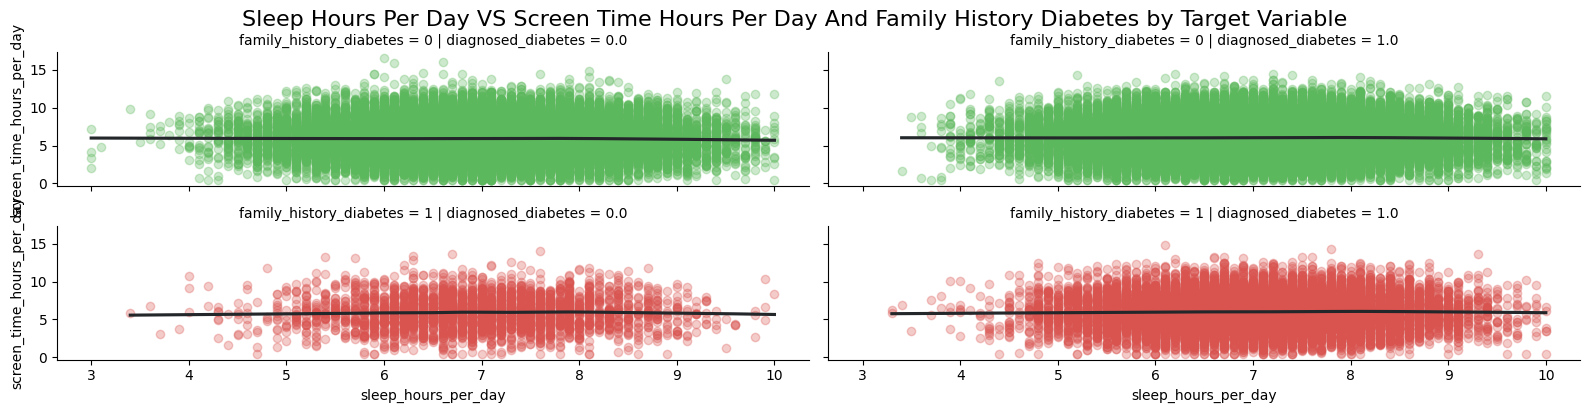

In [24]:
plotlm(x_var = "sleep_hours_per_day" , y_var = "screen_time_hours_per_day", row_var = "family_history_diabetes", pal = palette_01)

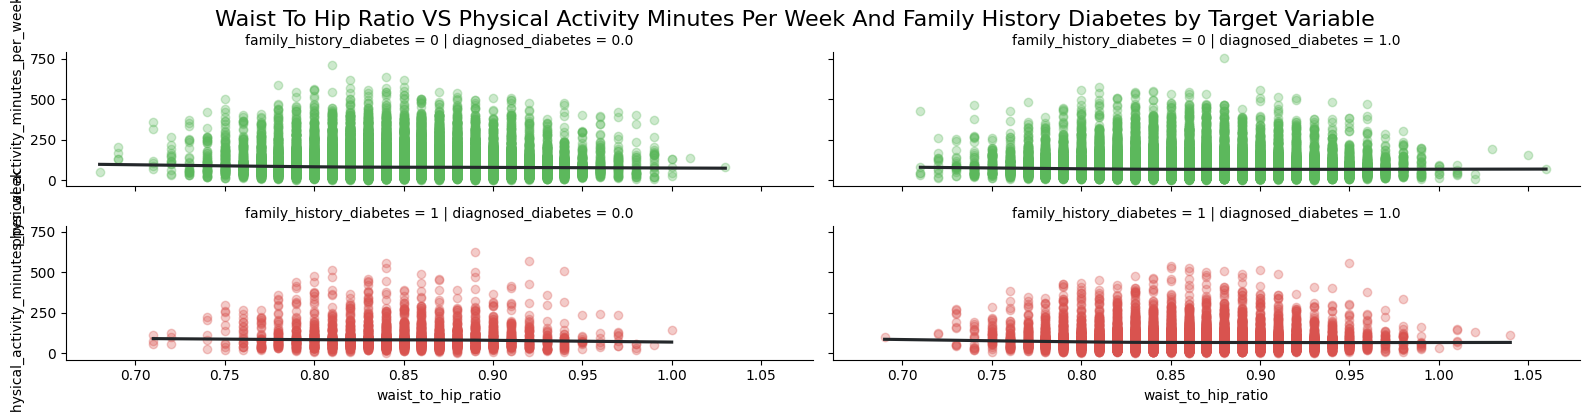

In [25]:
plotlm(x_var = "waist_to_hip_ratio" , y_var = "physical_activity_minutes_per_week",  row_var = "family_history_diabetes", pal = palette_01)

# Ethnicity

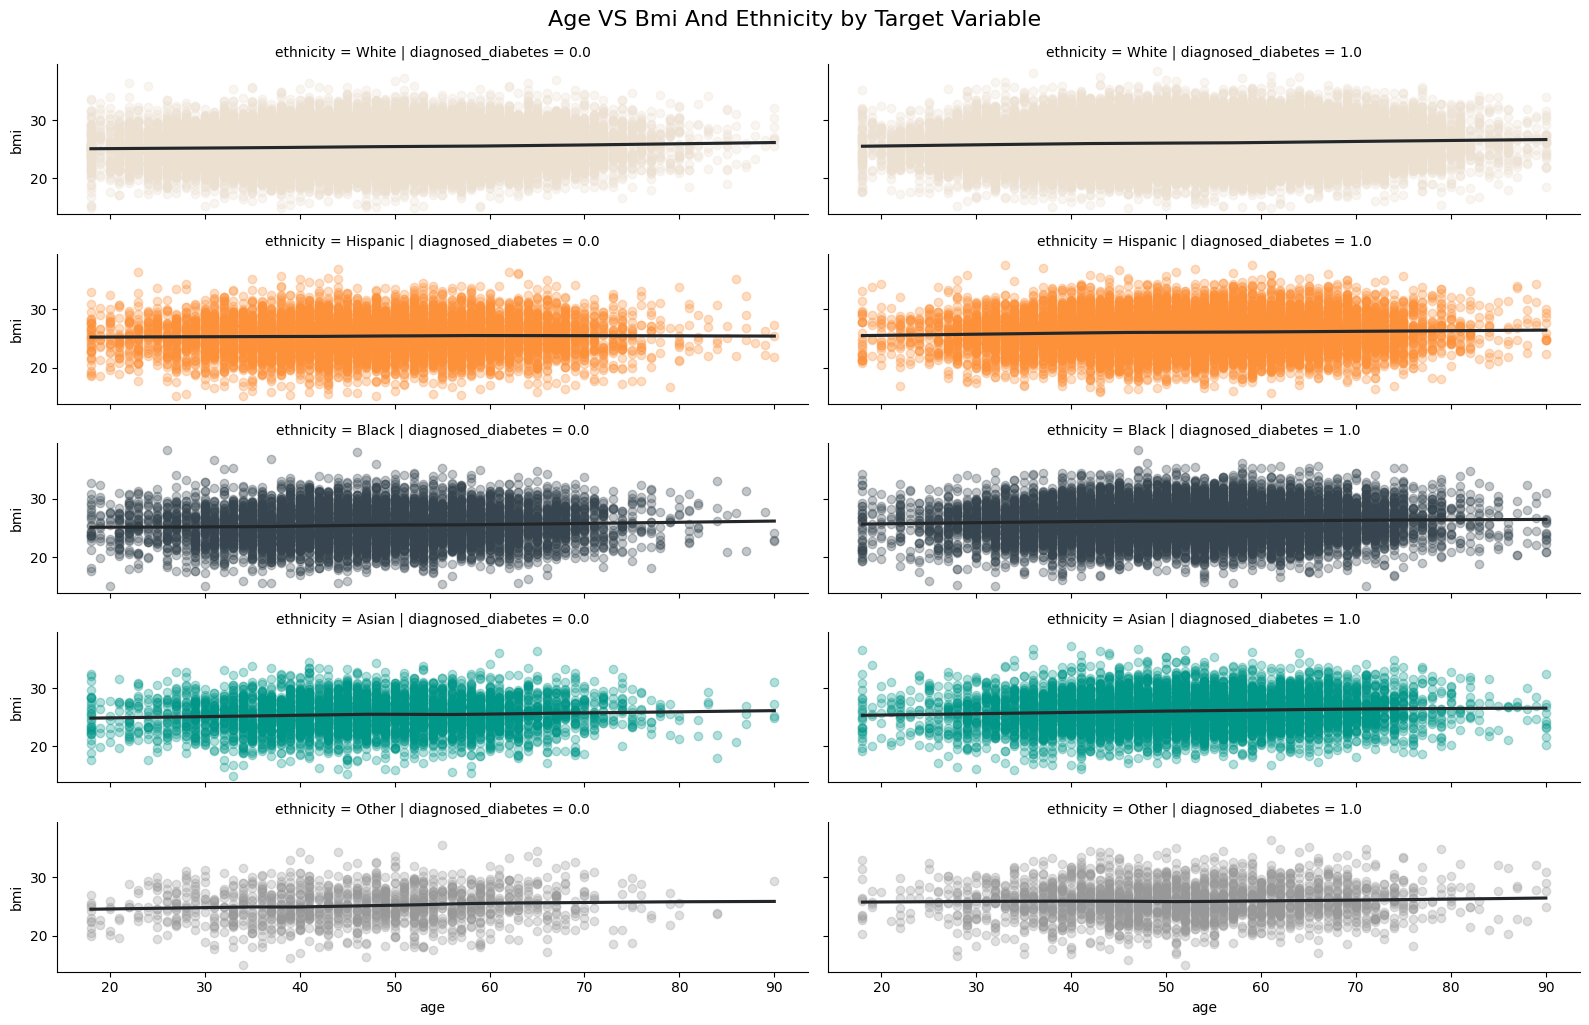

In [26]:
plotlm(x_var = "age" , y_var = "bmi",  row_var = "ethnicity", pal = pal_ethnicity)

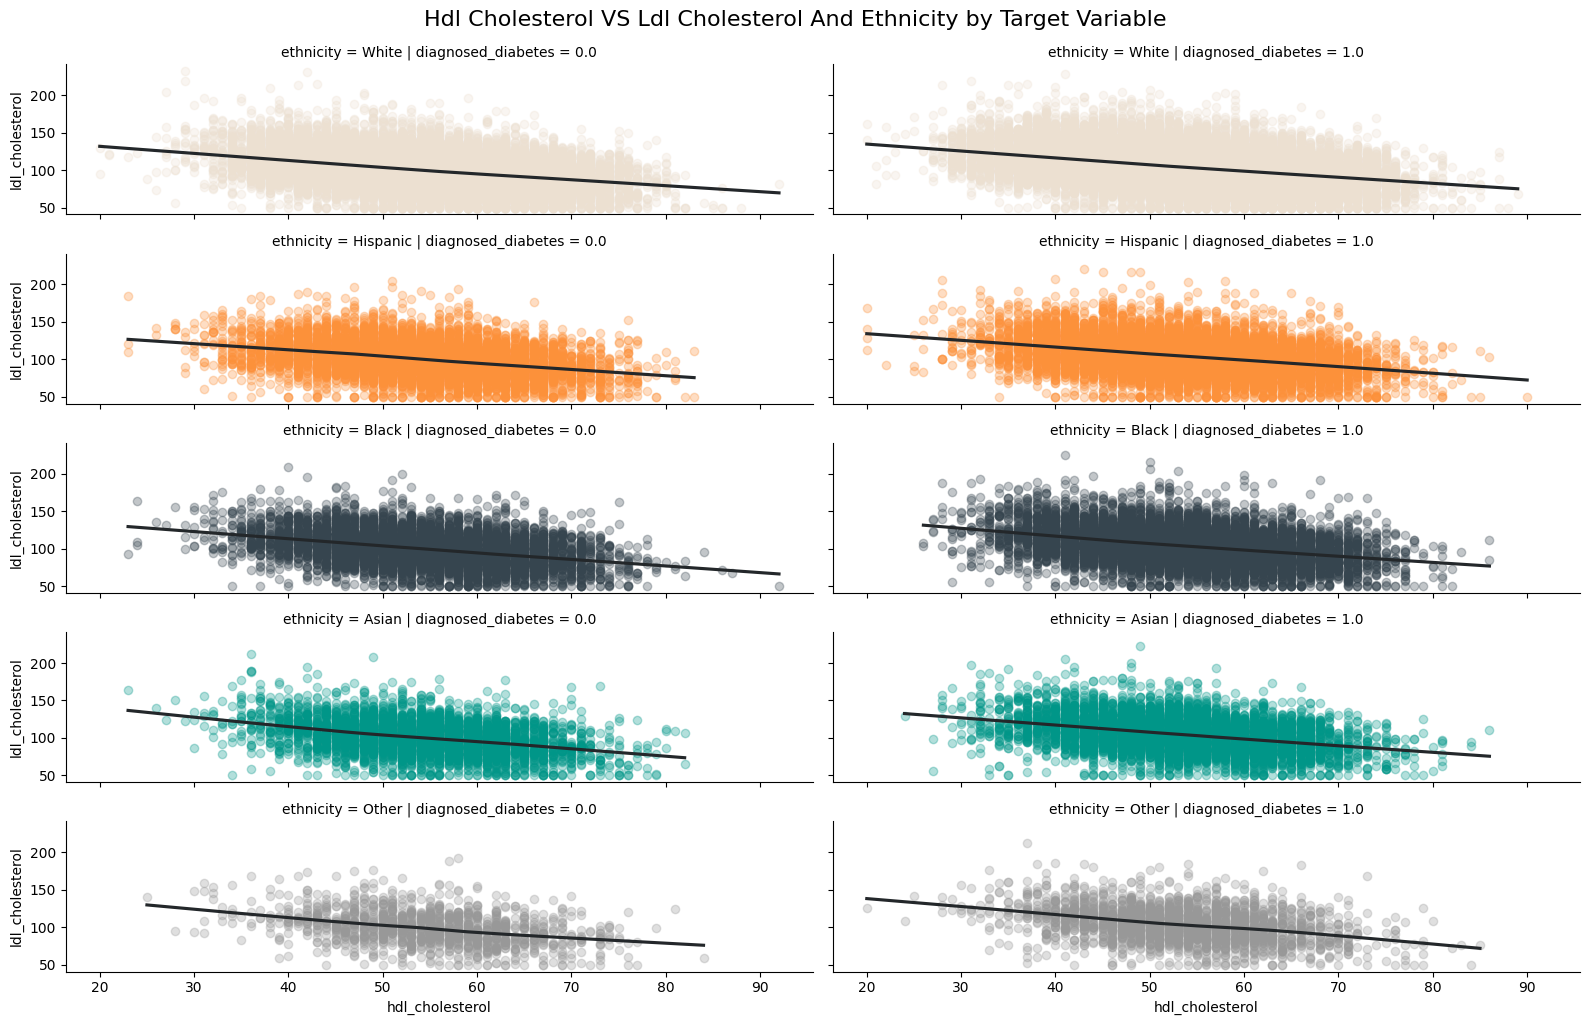

In [27]:
plotlm(x_var = "hdl_cholesterol" , y_var = "ldl_cholesterol", row_var = "ethnicity", pal = pal_ethnicity)

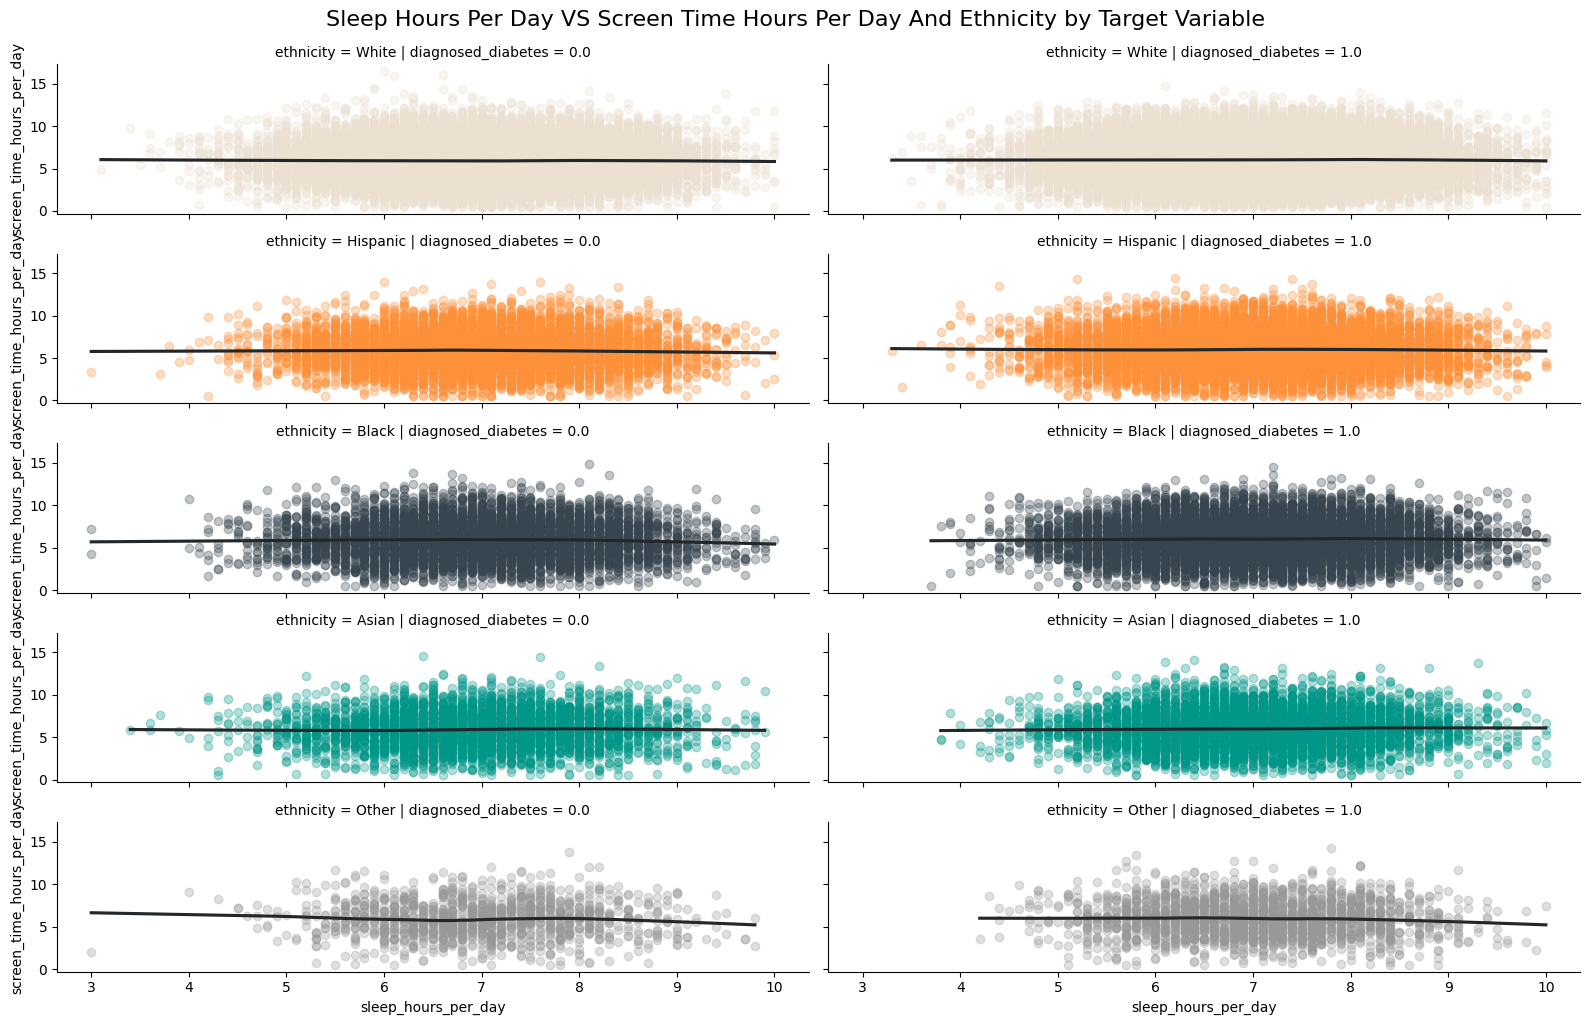

In [28]:
plotlm(x_var = "sleep_hours_per_day" , y_var = "screen_time_hours_per_day", row_var = "ethnicity", pal = pal_ethnicity)

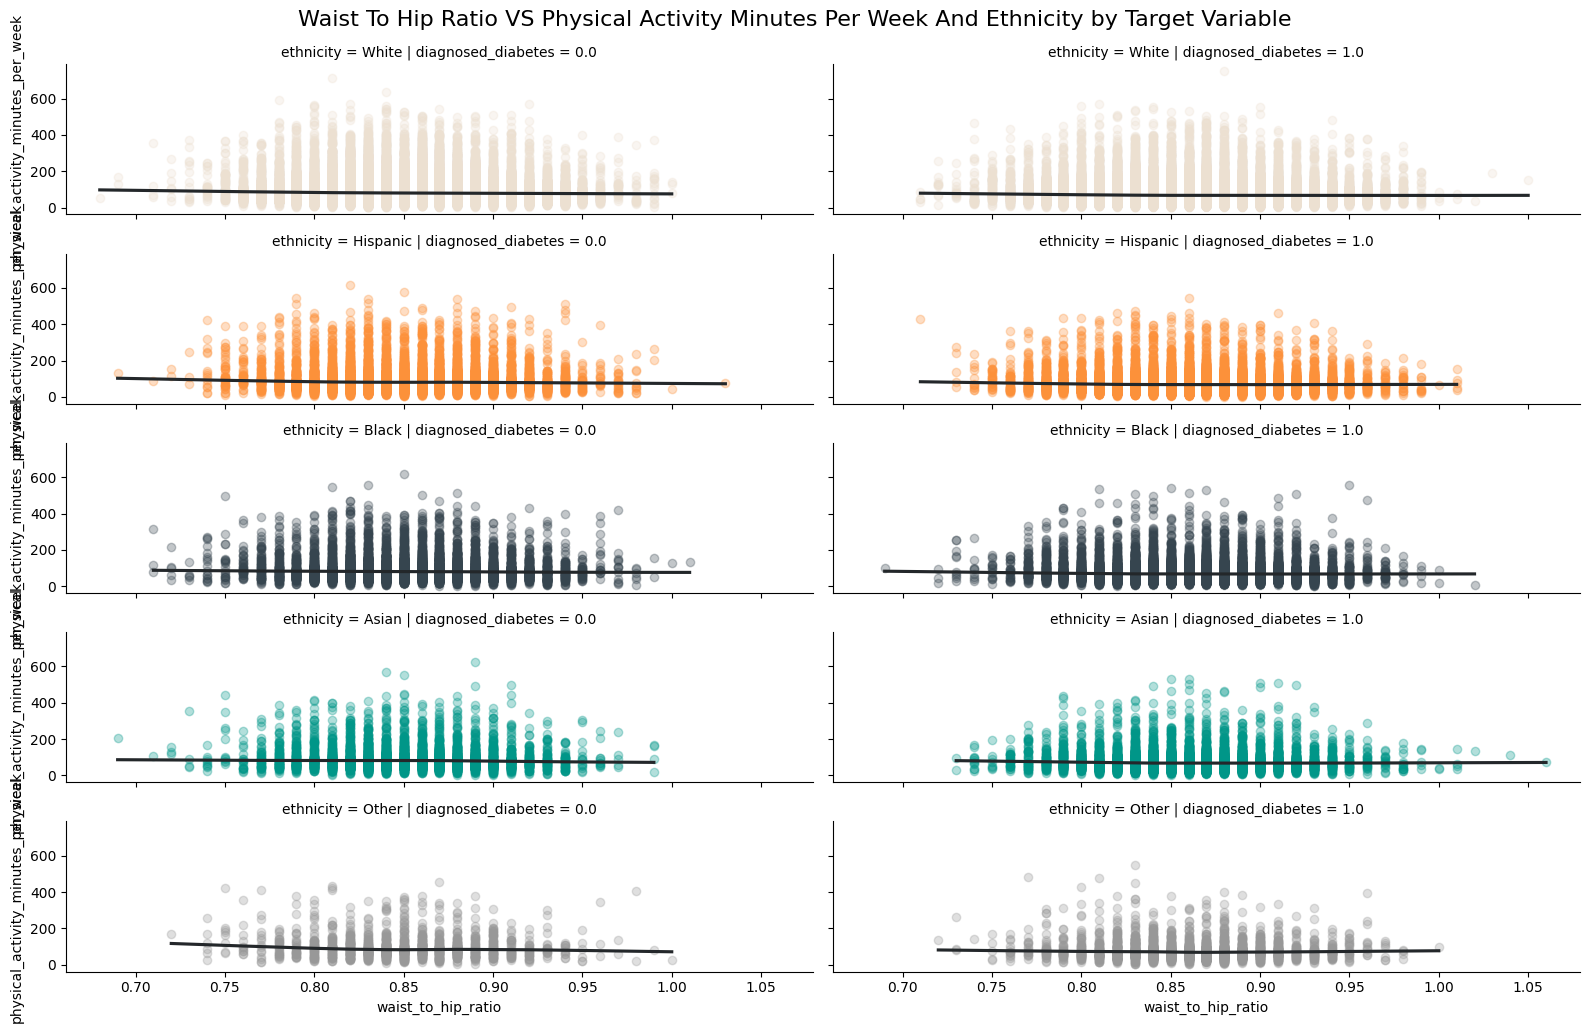

In [29]:
plotlm(x_var = "waist_to_hip_ratio" , y_var = "physical_activity_minutes_per_week",  row_var = "ethnicity", pal = pal_ethnicity)

# Model

## Preprocessing

In [30]:
# def create_frequency_features(df, df_test):

#     # Make copies to avoid modifying original DataFrames
#     df_processed = df.copy()
#     df_test_processed = df_test.copy()
    
    
#     # Frequency encoding for categorical columns
#     freq_maps = {}
#     for col in cat_cols:
#         if col in df_processed.columns:
#             # Calculate frequency on training data only
#             freq_map = df_processed[col].value_counts().to_dict()
#             freq_maps[col] = freq_map
            
#             # Apply to both train and test
#             df_processed[f"{col}_freq"] = df_processed[col].map(freq_map)
#             df_test_processed[f"{col}_freq"] = df_test_processed[col].map(freq_map).fillna(0)  # Fill unseen with 0
    
#     # Quantile binning for numeric columns
#     for col in num_cols_no_tar:
#         if col in df_processed.columns:
#             for q in [5, 10, 15]:
#                 try:
#                     # Create bins based on training data
#                     _, bins = pd.qcut(df_processed[col], q=q, retbins=True, duplicates='drop')
                    
#                     # Apply to training data
#                     df_processed[f"{col}_bin{q}"] = pd.cut(
#                         df_processed[col], bins=bins, labels=False, include_lowest=True
#                     ).fillna(-1).astype(int)
                    
#                     # Apply to test data (values outside bins become -1)
#                     df_test_processed[f"{col}_bin{q}"] = pd.cut(
#                         df_test_processed[col], bins=bins, labels=False, include_lowest=True
#                     ).fillna(-1).astype(int)
                    
#                 except Exception as e:
#                     # If binning fails, use simple scaling
#                     print(f"Binning failed for {col} with q={q}: {e}")
#                     df_processed[f"{col}_bin{q}"] = 0
#                     df_test_processed[f"{col}_bin{q}"] = 0
    
#     return df_processed, df_test_processed

In [31]:
def target_encoding_optimized(train, predict, target, cols, n_splits=10):

    # Work with minimal copies
    train_result = train.copy()
    predict_result = predict.copy()
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    overall_mean = train[target].mean()

    for col in cols:
        # Convert to categorical codes to save memory during processing
        train_codes = train[col].astype('category').cat.codes
        predict_codes = predict[col].astype('category').cat.codes
        
        # Calculate global means using codes (more memory efficient)
        code_to_global_mean = train.groupby(train_codes)[target].mean()
        
        # K-Fold encoding
        mean_encoded = np.full(len(train), overall_mean, dtype=np.float32)
        
        for tr_idx, val_idx in kf.split(train):
            tr_codes = train_codes.iloc[tr_idx]
            val_codes = train_codes.iloc[val_idx]
            tr_target = train[target].iloc[tr_idx]
            
            # Calculate fold means
            fold_means = tr_target.groupby(tr_codes).mean()
            
            # Map validation codes to fold means
            val_means = val_codes.map(fold_means)
            
            # Fill missing with global means
            nan_mask = val_means.isna()
            if nan_mask.any():
                val_means[nan_mask] = val_codes.map(code_to_global_mean)[nan_mask]
            
            mean_encoded[val_idx] = val_means.fillna(overall_mean).values
        
        train_result[f'mean_{col}'] = mean_encoded
        
        # Test data encoding
        test_encoded = predict_codes.map(code_to_global_mean).fillna(overall_mean)
        predict_result[f'mean_{col}'] = test_encoded.astype(np.float32).values
    
    return train_result, predict_result

## Apply functions

In [32]:
#train_df, test_df = create_frequency_features(train_df, test_df)

train_encoded, test_encoded = target_encoding_optimized(
    train_df, 
    test_df, 
    target='diagnosed_diabetes', 
    cols=cat_cols,
    n_splits=5
)

In [33]:
def convert_dtype(df):
    df = df.copy()
    df = df.astype({col: "category" for col in df.select_dtypes("object").columns})
    
    return df

train_df_preproc = convert_dtype(train_encoded)
test_df_preproc = convert_dtype(test_encoded)

num_cols_preproc = test_df_preproc.select_dtypes(include="number").columns

In [34]:
num_cols_preproc

Index(['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'mean_gender', 'mean_ethnicity',
       'mean_education_level', 'mean_income_level', 'mean_smoking_status',
       'mean_employment_status'],
      dtype='object')

In [35]:
train_df_preproc

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes,mean_gender,mean_ethnicity,mean_education_level,mean_income_level,mean_smoking_status,mean_employment_status
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,...,0,0,0,1.0,0.619509,0.613204,0.619266,0.624558,0.618765,0.622007
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,...,0,0,0,1.0,0.619318,0.621851,0.618913,0.617426,0.620866,0.622643
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,...,0,0,0,0.0,0.620608,0.613204,0.619266,0.624558,0.620011,0.614403
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,...,0,1,0,1.0,0.619087,0.621347,0.619092,0.623487,0.619162,0.622096
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,...,0,1,0,1.0,0.621652,0.621851,0.618913,0.617426,0.620866,0.613665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,1,136,8.3,6.4,4.5,29.8,0.93,126,74,...,0,0,0,0.0,0.621532,0.629352,0.624067,0.617936,0.621565,0.618882
99996,41,3,76,8.8,6.8,4.8,26.5,0.86,130,76,...,0,0,0,0.0,0.619087,0.621347,0.623803,0.618246,0.620382,0.622096
99997,57,4,121,9.9,5.0,6.1,25.6,0.83,107,87,...,0,0,1,0.0,0.619203,0.621177,0.625101,0.617903,0.620405,0.622005
99998,47,3,52,5.9,6.7,0.5,26.8,0.89,115,77,...,0,1,0,0.0,0.619487,0.620120,0.619335,0.624261,0.620536,0.614420


In [36]:
def encode_categorical(tr_df, ts_df, cols):
    for col in cols:
        le = LabelEncoder()
        tr_df[col] = le.fit_transform(tr_df[col].astype(str))
        ts_df[col] = le.transform(
            ts_df[col]
            .astype(str)
            .map(lambda x: x if x in le.classes_ else le.classes_[0])
        )
    return tr_df, ts_df


# Apply encoding
train, test = encode_categorical(train_df_preproc, test_df_preproc, cat_cols)


scaler = StandardScaler()
train[num_cols_preproc] = scaler.fit_transform(train[num_cols_preproc])
test[num_cols_preproc] = scaler.transform(test[num_cols_preproc])

In [37]:
X = train.drop(columns=["diagnosed_diabetes"])
y = train["diagnosed_diabetes"].astype("int16")
X_test = test

In [38]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 30 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 300000 non-null  float64
 1   alcohol_consumption_per_week        300000 non-null  float64
 2   physical_activity_minutes_per_week  300000 non-null  float64
 3   diet_score                          300000 non-null  float64
 4   sleep_hours_per_day                 300000 non-null  float64
 5   screen_time_hours_per_day           300000 non-null  float64
 6   bmi                                 300000 non-null  float64
 7   waist_to_hip_ratio                  300000 non-null  float64
 8   systolic_bp                         300000 non-null  float64
 9   diastolic_bp                        300000 non-null  float64
 10  heart_rate                          300000 non-null  float64
 11  cholesterol_total         

### LGBMRegressor Model

In [39]:
# ### Hyperparameter Tuning (Optuna)

# def objective_lgbm(trial):

#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y, test_size=0.25, random_state=rand_seed
#     )

#     lgbm_params = {
#         "device": (
#             "gpu" if LGBMClassifier().get_params().get("device") == "gpu" else "cpu"
#         ),
#         "metric": "auc",
#         "n_estimators": trial.suggest_int("n_estimators", 800, 1800),
#         "num_leaves": trial.suggest_int("num_leaves", 70, 110),
#         "max_depth": trial.suggest_int("max_depth", 4, 15),
#         "learning_rate": trial.suggest_float("learning_rate", 1e-2, 0.09),
#         "subsample": trial.suggest_uniform("subsample", 0.8, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.9),
#         "reg_alpha": trial.suggest_float("reg_alpha", 6.1, 7.2),
#         "reg_lambda": trial.suggest_float("reg_lambda", 0.01, 0.04),
#     }

#     # Fit the model
#     model_lgbm = LGBMClassifier(**lgbm_params, 
#                                 random_state=rand_seed, 
#                                 verbose=-1)

#     model_lgbm.fit(X_train, y_train)

#     # Predict and calculate accuracy score
#     y_pred = model_lgbm.predict(X_test)

#     return  accuracy_score(y_test, y_pred)

### Create a study object | optimization

In [40]:
# study_lgbm = optuna.create_study(study_name="LGBM_diabetes", direction="maximize")
# optuna.logging.set_verbosity(optuna.logging.WARNING)
# study_lgbm.optimize(objective_lgbm, n_trials=400, show_progress_bar=True)

## Best trial

In [41]:
# print("Best trial:", study_lgbm.best_trial)

## Best parameters

In [42]:
# print("Best parameters:", study_lgbm.best_params)

## Train and LGBMClassifier

In [43]:
best_parameters = {'n_estimators': 1414,
                  'num_leaves': 99, 
                  'max_depth': 4, 
                  'learning_rate': 0.0811563529212108, 
                  'subsample': 0.8013276891512052, 
                  'colsample_bytree': 0.880771415168706, 
                  'reg_alpha': 6.519661725929783, 
                  'reg_lambda': 0.03006704024250326,
                  'path_smooth': 17
                  }

model = LGBMClassifier(
    **best_parameters,
    random_state=rand_seed,
    verbose = -1
)

model.fit(
    X,
    y
)


LGBMClassifier(colsample_bytree=0.880771415168706,
               learning_rate=0.0811563529212108, max_depth=4, n_estimators=1414,
               num_leaves=99, path_smooth=17, random_state=7,
               reg_alpha=6.519661725929783, reg_lambda=0.03006704024250326,
               subsample=0.8013276891512052, verbose=-1)

## Feature Importance

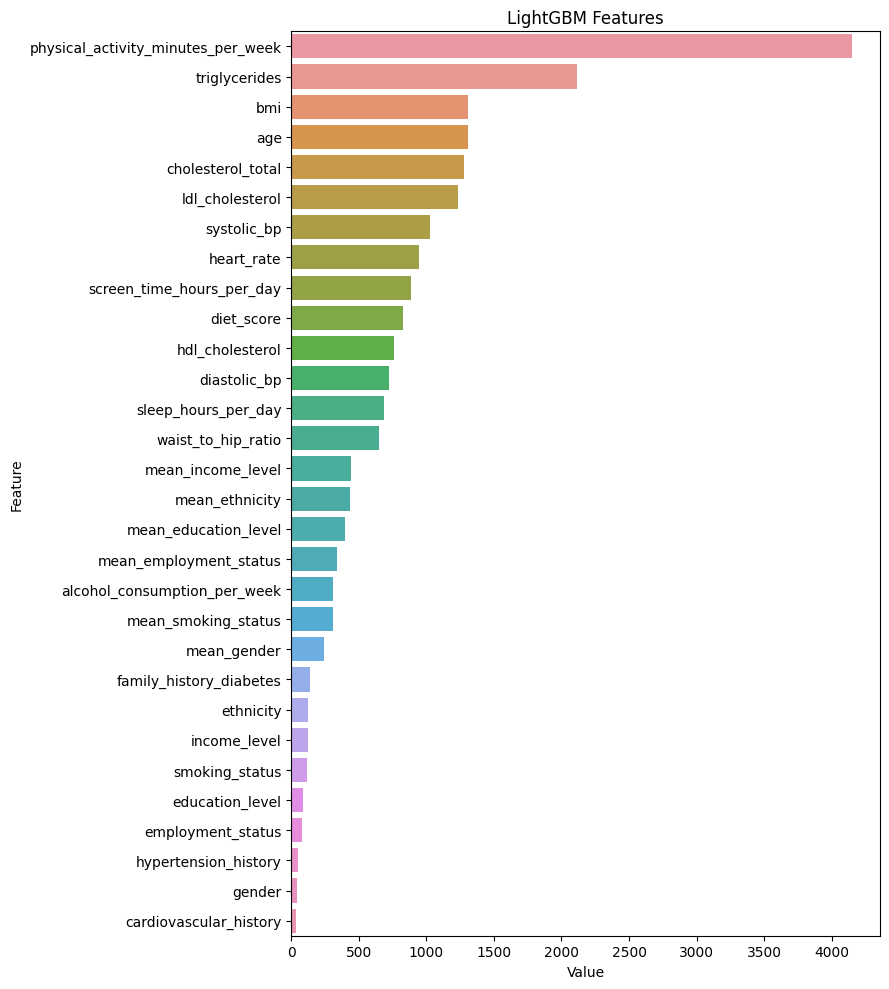

In [44]:

feature_importances = model.feature_importances_

feature_imp = pd.DataFrame(sorted(zip(model.feature_importances_, X.columns)), columns=['Value','Feature'])

plt.figure(figsize=(9, 10))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False))
plt.title('LightGBM Features')
plt.tight_layout()
plt.show()

## Prediction

In [45]:

pred_lgb = model.predict_proba(X_test)[:,1]

pred_lgb

array([0.4582097 , 0.68070901, 0.76174777, ..., 0.60669296, 0.61182043,
       0.62364516])

### Update submission "diagnosed_diabetes" variable

In [46]:
submission["diagnosed_diabetes"] = pred_lgb

### Submit

In [47]:
submission.to_csv("submission.csv", index=False)
submission.head()

,id,diagnosed_diabetes
0,700000,0.458210
1,700001,0.680709
2,700002,0.761748
3,700003,0.431189
4,700004,0.909573


In [48]:
session_info.show(html = False)

-----
lightgbm            4.6.0
matplotlib          3.7.2
numpy               1.26.4
optuna              4.5.0
pandas              2.2.3
seaborn             0.12.2
session_info        v1.0.1
sklearn             1.2.2
-----
IPython             7.34.0
jupyter_client      8.6.3
jupyter_core        5.8.1
jupyterlab          3.6.8
notebook            6.5.4
-----
Python 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
Linux-6.6.105+-x86_64-with-glibc2.35
-----
Session information updated at 2025-12-17 09:59
